In [1]:
# idk this will do stuff
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
from aqa_parsing_utilities import *
from data_center_model import *
from training_utilities import *
from sklearn.preprocessing import normalize

In [2]:
# Makes data center model, a neural network
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# medium
sim_model = DataCenterModel()
sim_model.to(device)
sim_model.train()
print('')

In [3]:
# Trains model
sim_model, train_loss_record, test_loss_record = train_model(sim_model,epochs=150,lr=1e-4,batch_size=512,verbose=True,cross_validate=False)

c:\Users\qtcc\miniconda3\envs\rl\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch 0 Loss: 111.29708664326728
Epoch 1 Loss: 102.23716663408884
Epoch 2 Loss: 101.6715667821184
Epoch 3 Loss: 100.69682471359832
Epoch 4 Loss: 95.82550821425039
Epoch 5 Loss: 80.54182830037949
Epoch 6 Loss: 59.65026691291906
Epoch 7 Loss: 41.645887809463694
Epoch 8 Loss: 32.56992312322689
Epoch 9 Loss: 28.80375542218172
Epoch 10 Loss: 27.063106766229943
Epoch 11 Loss: 25.877326796326457
Epoch 12 Loss: 25.76509888564484
Epoch 13 Loss: 25.2679263127001
Epoch 14 Loss: 25.086303916158556
Epoch 15 Loss: 24.690163298498227
Epoch 16 Loss: 24.398978257481055
Epoch 17 Loss: 24.300058401083643
Epoch 18 Loss: 23.713727528535866
Epoch 19 Loss: 23.555017423026168
Epoch 20 Loss: 22.702276616156855
Epoch 21 Loss: 22.25088487697553
Epoch 22 Loss: 21.683796556690073
Epoch 23 Loss: 20.803283606903463
Epoch 24 Loss: 19.806136348579503
Epoch 25 Loss: 18.874489114254335
Epoch 26 Loss: 17.545517867124534
Epoch 27 Loss: 16.494848770431325
Epoch 28 Loss: 15.879933737501313
Epoch 29 Loss: 14.685528447356406


In [5]:
2.616*10**-5

2.6160000000000004e-05

In [ ]:
starting_epoch = 20
plt.title('Training Graph')
plt.plot(range(len(train_loss_record[starting_epoch:])),train_loss_record[starting_epoch:],label='Train')
if len(test_loss_record) != 0: 
    plt.plot(range(len(test_loss_record[starting_epoch:])),test_loss_record[starting_epoch:],label='Test')
plt.legend()

In [ ]:
torch.save(sim_model,'models/model_v2_1.pth')

In [2]:
sim_model = torch.load('models/model_v2_1.pth')
sim_model.eval()
y_true_train,y_pred_train,y_true_test,y_pred_test = evaluate_model(sim_model,cross_validate = True)

MSE  || Train: 2.8640776 | Test: 2.9148633
MAPE || Train: 79672074000.0 | Test: 43.568226


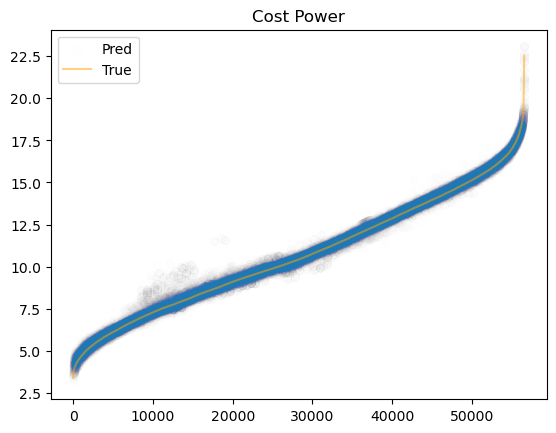

In [3]:
plt.title('Cost Power')
ind = np.argsort(y_true_train[:,0], axis=0)
plt.scatter(range(len(y_pred_train[:,0])),np.take_along_axis(y_pred_train[:,0], ind, axis=0),alpha=.005,label='Pred')
plt.plot(range(len(y_true_train[:,0])),np.take_along_axis(y_true_train[:,0], ind, axis=0),alpha=0.5,label='True',c='Orange')
plt.legend()

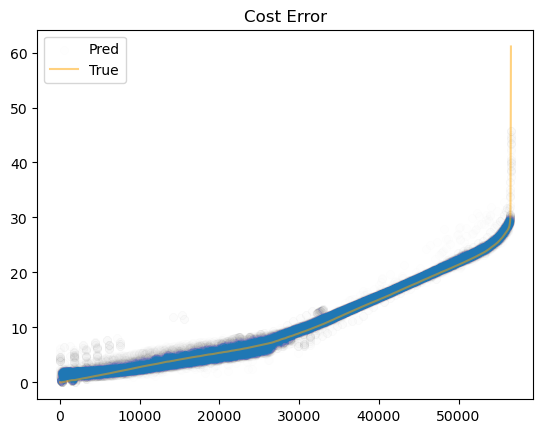

In [4]:
plt.title('Cost Error')
ind = np.argsort(y_true_train[:,1], axis=0)
plt.scatter(range(len(y_pred_train[:,1])),np.take_along_axis(y_pred_train[:,1], ind, axis=0),alpha=.005,label='Pred')
plt.plot(range(len(y_true_train[:,1])),np.take_along_axis(y_true_train[:,1], ind, axis=0),alpha=0.5,label='True',c='orange')
plt.legend()

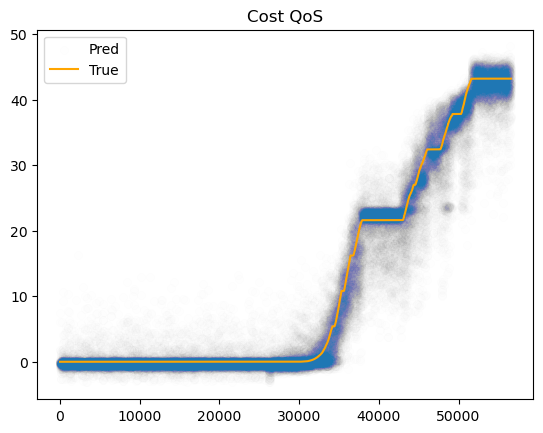

In [5]:
plt.title('Cost QoS')
ind = np.argsort(y_true_train[:,2], axis=0)

plt.scatter(range(len(y_pred_train[:,2])),np.take_along_axis(y_pred_train[:,2], ind, axis=0),alpha=.005,label='Pred')
plt.plot(range(len(y_true_train[:,2])),np.take_along_axis(y_true_train[:,2], ind, axis=0),alpha=1,label='True',c='Orange')
plt.legend()